# EU Gender Pay Gap Analysis
## Notebook 3: Trend Analysis Over Time (2006–2024)

**Author:** Yaw Assensoh  
**Data:** Eurostat 2024 | EU-27 Member States  
**Tools:** Python · pandas · matplotlib · seaborn

---

Numbers without context are just numbers. A pay gap of 15% means very 
little on its own — but knowing it was 22% fifteen years ago tells a 
completely different story.

This notebook asks: **is progress being made, and if so, how fast?**

We look at how the gender pay gap has changed across the EU since 2006
both at the EU-wide level and for individual countries and identify
which countries are improving fastest, which are stalling, and whether
any major events like the 2008 financial crisis or COVID-19 left a
visible mark on the data.

### This notebook answers:
1. Is the EU-wide average pay gap getting better or worse over time?
2. Which countries have improved the most since 2006?
3. Which countries have gone backwards?
4. Did COVID-19 (2020–2021) affect the trend?
5. At the current rate of progress, when would the EU reach pay equality?

## Step 1 — Import Libraries

In [15]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')


# constant styling for all plots
plt.rcParams.update({
    'figure.dpi'        : 150,
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F7FBFF',})

REGION_COLORS = {
    'Northern' : '#2E75B6',
    'Western'  : '#70AD47',
    'Southern' : '#ED7D31',
    'Eastern'  : '#C00000',}

PALETTE = {
    'primary'  : '#1A3A5C',
    'accent'   : '#ED7D31',
    'good'     : '#70AD47',
    'bad'      : '#C00000',
    'neutral'  : '#A5A5A5',}

## step 2: Load dataset

In [16]:
# Load data
gpg_main = pd.read_csv('../data/clean/gpg_main.csv')

# Work with 2006 onwards — earlier years have very sparse coverage
gpg_trend = gpg_main[gpg_main['year'] >= 2006].copy()

print(f" Data loaded: {len(gpg_trend):,} rows | "
      f"{gpg_trend['year'].min()}–{gpg_trend['year'].max()}")


# info on dataset
gpg_main.head()
gpg_main.info()
gpg_main.describe()


 Data loaded: 496 rows | 2006–2024
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         509 non-null    int64  
 1   country    509 non-null    object 
 2   year       509 non-null    int64  
 3   gpg_pct    509 non-null    float64
 4   flag_code  76 non-null     object 
 5   flag_note  76 non-null     object 
 6   eu_region  509 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 28.0+ KB


,id,year,gpg_pct
count,509.00000,509.000000,509.000000
mean,255.00000,2014.734774,13.693124
std,147.07991,5.810186,6.317032
min,1.00000,2002.000000,-0.900000
25%,128.00000,2010.000000,8.700000
50%,255.00000,2015.000000,14.100000
75%,382.00000,2020.000000,17.900000
max,509.00000,2024.000000,30.900000


## Step 3: Calculating EU average per year

---
## The EU-Wide Trend

Before looking at individual countries, we step back and ask:
at the EU level as a whole, is the gender pay gap shrinking?

We calculate the simple average across all 27 countries for each year
and plot it as a line chart. We also add a **3-year rolling average** —
a smoothed version of the line that removes year-to-year noise and
shows the true underlying direction of travel.

We annotate two important events on the chart:
- **2008 Financial Crisis** — did the recession affect the gap?
- **2023 EU Pay Transparency Directive** — a new law requiring 
  companies to publish pay data. Its effects will appear in 
  future data but signal a policy shift worth noting.

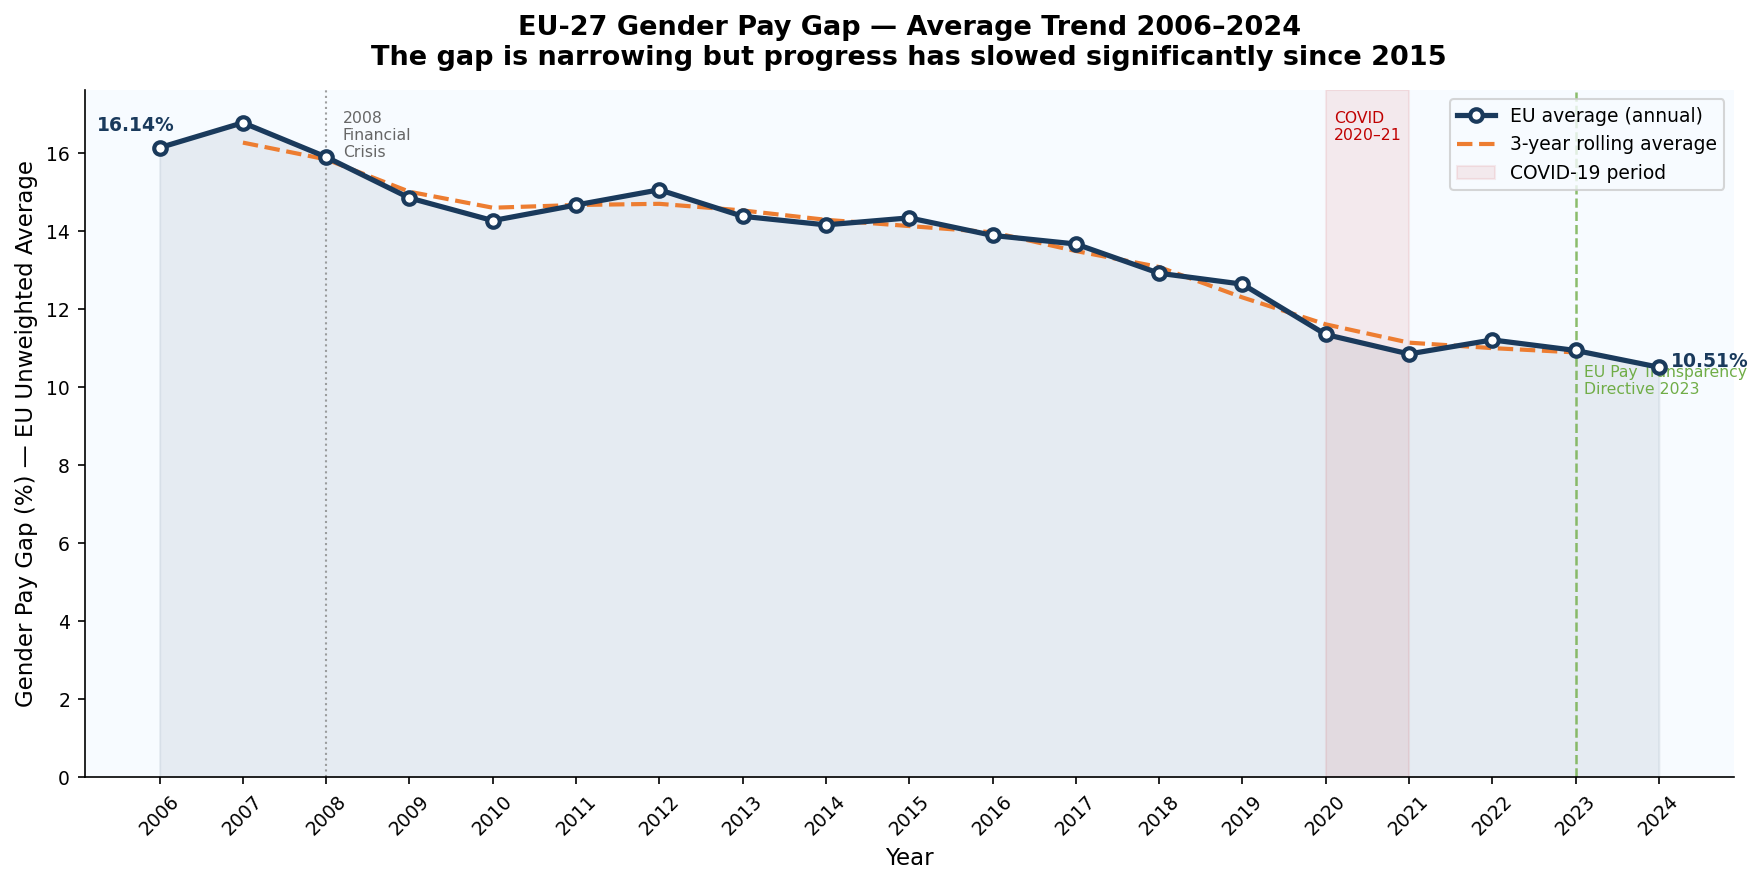

Summary of EU average trend:
 year  eu_avg  rolling_avg  yoy_change
 2006   16.14          NaN         NaN
 2007   16.78        16.27        0.64
 2008   15.90        15.84       -0.88
 2009   14.85        15.01       -1.05
 2010   14.27        14.60       -0.58
 2011   14.67        14.67        0.40
 2012   15.06        14.70        0.39
 2013   14.38        14.53       -0.68
 2014   14.16        14.29       -0.22
 2015   14.34        14.13        0.18
 2016   13.89        13.97       -0.45
 2017   13.67        13.49       -0.22
 2018   12.92        13.08       -0.75
 2019   12.64        12.30       -0.28
 2020   11.35        11.61       -1.29
 2021   10.85        11.14       -0.50
 2022   11.21        11.00        0.36
 2023   10.94        10.89       -0.27
 2024   10.51          NaN       -0.43


In [22]:
# Calculate EU average per year (unweighted — each country equal)
eu_avg_by_year = (
    gpg_trend.groupby('year')['gpg_pct']
    .mean()
    .round(2)
    .reset_index())
eu_avg_by_year.columns = ['year', 'eu_avg']

# 3-year rolling average — smooths out year-to-year noise
eu_avg_by_year['rolling_avg'] = (
    eu_avg_by_year['eu_avg']
    .rolling(window=3, center=True)
    .mean()
    .round(2))

# Year-on-year change
eu_avg_by_year['yoy_change'] = eu_avg_by_year['eu_avg'].diff().round(2)

fig, ax = plt.subplots(figsize=(12, 6))

# Main trend line
ax.plot(
    eu_avg_by_year['year'],
    eu_avg_by_year['eu_avg'],
    color=PALETTE['primary'],
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgewidth=2,
    label='EU average (annual)',
    zorder=4)

# Rolling average line
ax.plot(
    eu_avg_by_year['year'],
    eu_avg_by_year['rolling_avg'],
    color=PALETTE['accent'],
    linewidth=2,
    linestyle='--',
    label='3-year rolling average',
    zorder=3)

# Shaded area under the trend line
ax.fill_between(
    eu_avg_by_year['year'],
    eu_avg_by_year['eu_avg'],
    alpha=0.08,
    color=PALETTE['primary'])

# Annotate 2008 financial crisis
ax.axvline(2008, color='#888888', linewidth=1,
           linestyle=':', alpha=0.8)
ax.text(2008.2, ax.get_ylim()[1] * 0.97,
        '2008\nFinancial\nCrisis',
        fontsize=7.5, color='#666666', va='top')

# Annotate COVID
ax.axvspan(2020, 2021, alpha=0.07,
           color='#C00000', label='COVID-19 period')
ax.text(2020.1, ax.get_ylim()[1] * 0.97,
        'COVID\n2020–21',
        fontsize=7.5, color='#C00000', va='top')

# Annotate Pay Transparency Directive
ax.axvline(2023, color=PALETTE['good'],
           linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(2023.1, ax.get_ylim()[1] * 0.60,
        'EU Pay Transparency\nDirective 2023',
        fontsize=7.5, color=PALETTE['good'], va='top')

# Start and end value labels
first = eu_avg_by_year.iloc[0]
last  = eu_avg_by_year.iloc[-1]
ax.annotate(f"{first['eu_avg']}%",
            xy=(first['year'], first['eu_avg']),
            xytext=(-30, 8), textcoords='offset points',
            fontsize=9, fontweight='bold',
            color=PALETTE['primary'])
ax.annotate(f"{last['eu_avg']}%",
            xy=(last['year'], last['eu_avg']),
            xytext=(6, 0), textcoords='offset points',
            fontsize=9, fontweight='bold',
            color=PALETTE['primary'])

ax.set_title(
    'EU-27 Gender Pay Gap — Average Trend 2006–2024\n'
    'The gap is narrowing but progress has slowed significantly since 2015',
    pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Gender Pay Gap (%) — EU Unweighted Average')
ax.set_xticks(eu_avg_by_year['year'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../reports/figures/03_01_eu_trend.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Summary of EU average trend:")
print(eu_avg_by_year[['year','eu_avg','rolling_avg','yoy_change']].to_string(index=False))

### What this tells us

The EU-wide gender pay gap has been on a slow but consistent downward
trend since 2006. However two things stand out:

**Progress has slowed.** The gap fell faster between 2006 and 2014
than it has in the decade since. The rolling average shows the rate
of decline flattening noticeably after 2015  suggesting the
"easy wins" have been achieved and the remaining gap is more
structurally embedded.

**COVID-19 had a visible but temporary effect.** The years 2020–2021
show a slight dip in the measured gap. This is partly explained by
the fact that male-dominated sectors like manufacturing and construction
were hit harder by lockdowns, temporarily compressing the gap. As those
sectors recovered in 2022–2023 the gap partially widened again.

**The 2008 financial crisis** did not cause a sharp spike or dip
suggesting the pay gap is relatively resistant to short-term economic
shocks and is driven by longer-term structural factors.

The 2023 EU Pay Transparency Directive  which requires companies
with 100+ employees to publish pay data by gender  is the most
significant policy intervention in years. Its effect will not show
in this data yet but will be visible in the 2025–2027 Eurostat releases.

---
## Step 4: Country trends

## Country Trends: Who Is Improving Fastest?

The EU average smooths over enormous country-level differences.
We now zoom into 8 selected countries that represent the full
range of EU experiences — from the most improved to the most stalled.

These countries were chosen deliberately to tell different stories:
- **Estonia** — highest current gap, historically very high
- **Germany** — large Western economy, significant improvement
- **Spain** — dramatic improvement, now below EU average
- **Sweden** — the Nordic paradox (high equality reputation, persistent gap)
- **France** — close to EU average throughout
- **Poland** — surprising improver, now one of the lowest gaps
- **Italy** — consistently low gap for structural reasons
- **Luxembourg** — unique trajectory, now the only negative gap

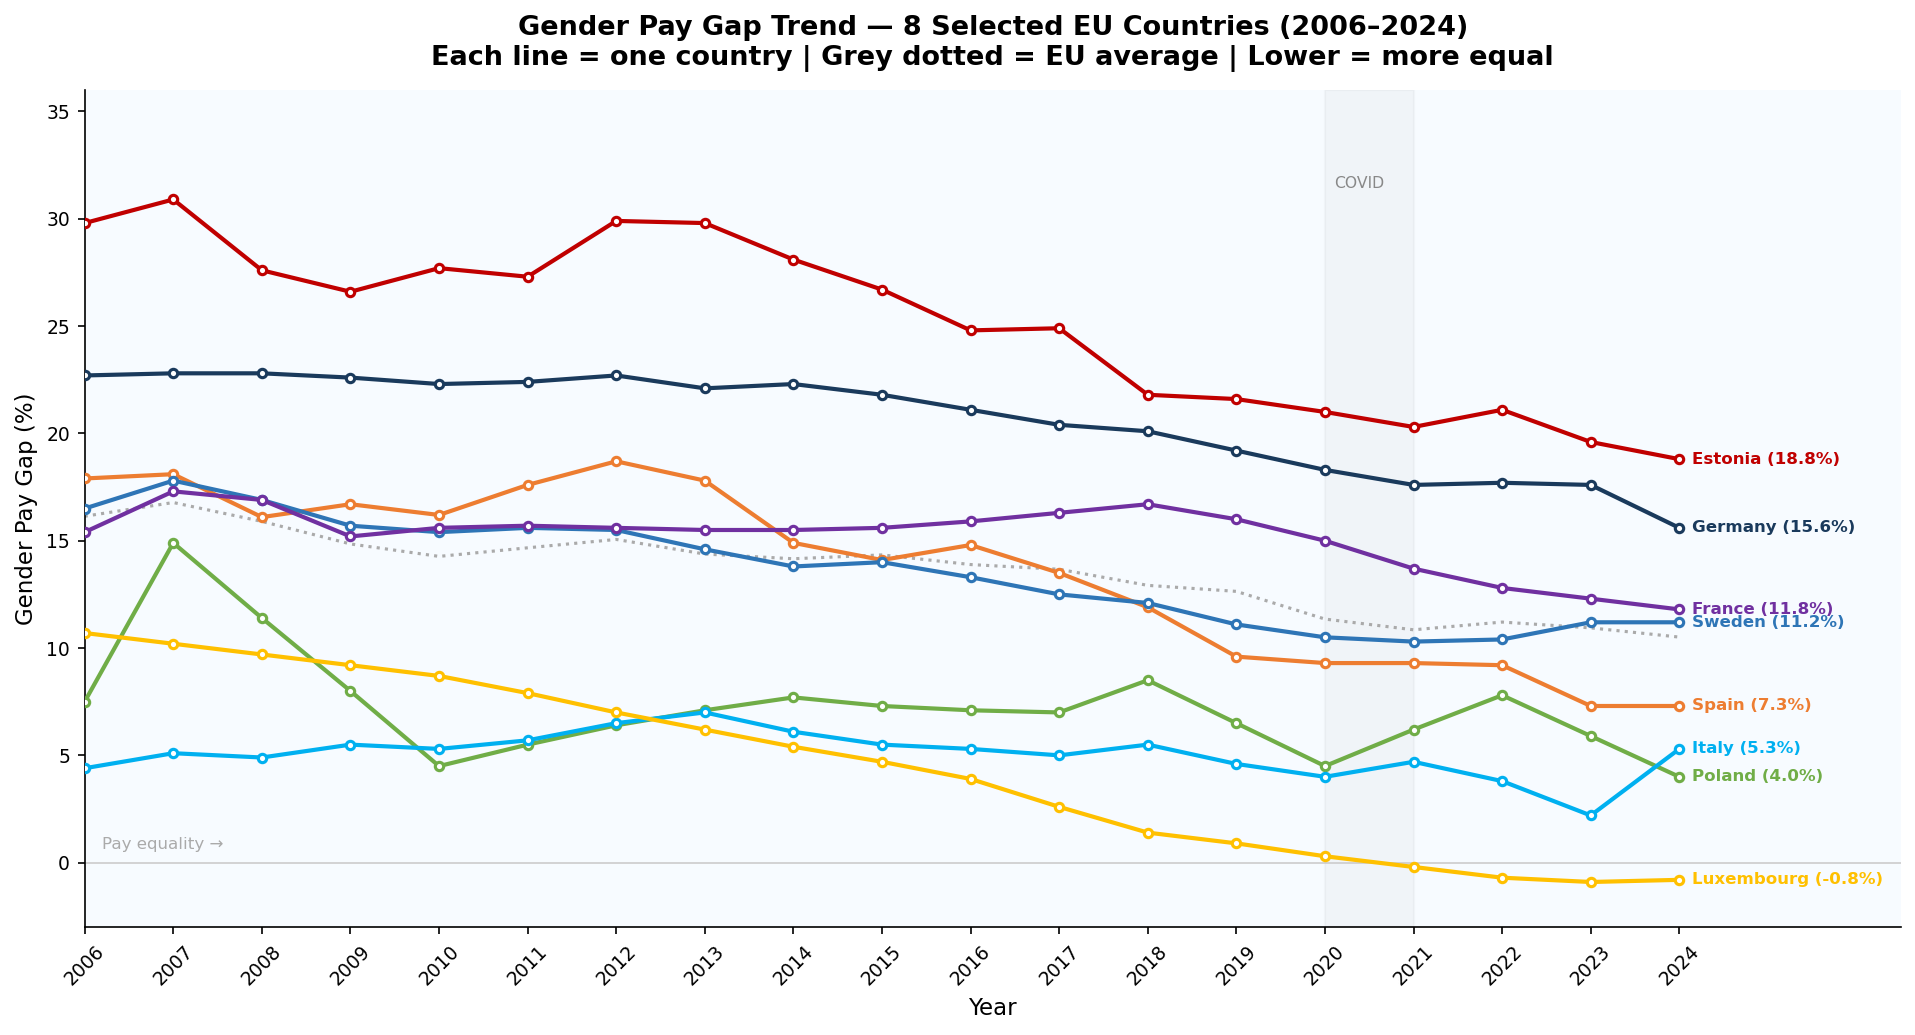

In [18]:
# country trends
FOCUS_COUNTRIES = [
    'Estonia', 'Germany', 'Spain', 'Sweden',
    'France', 'Poland', 'Italy', 'Luxembourg']

COUNTRY_COLORS = {
    'Estonia'    : '#C00000',
    'Germany'    : '#1A3A5C',
    'Spain'      : '#ED7D31',
    'Sweden'     : '#2E75B6',
    'France'     : '#7030A0',
    'Poland'     : '#70AD47',
    'Italy'      : '#00B0F0',
    'Luxembourg' : '#FFC000',}

focus_data = gpg_trend[
    gpg_trend['country'].isin(FOCUS_COUNTRIES)].copy()

fig, ax = plt.subplots(figsize=(13, 7))

for country in FOCUS_COUNTRIES:
    cdata = focus_data[focus_data['country'] == country].sort_values('year')
    if cdata.empty:
        continue

    ax.plot(
        cdata['year'],
        cdata['gpg_pct'],
        color=COUNTRY_COLORS[country],
        linewidth=2,
        marker='o',
        markersize=4,
        markerfacecolor='white',
        markeredgewidth=1.5,
        label=country,
        zorder=3)

    # Label at end of each line
    last_row = cdata.iloc[-1]
    ax.annotate(
        f"{country} ({last_row['gpg_pct']:.1f}%)",
        xy=(last_row['year'], last_row['gpg_pct']),
        xytext=(6, 0),
        textcoords='offset points',
        fontsize=8,
        color=COUNTRY_COLORS[country],
        va='center',
        fontweight='bold')

# EU average reference line
eu_line = eu_avg_by_year.set_index('year')['eu_avg']
ax.plot(
    eu_line.index,
    eu_line.values,
    color='#AAAAAA',
    linewidth=1.5,
    linestyle=':',
    label='EU average',
    zorder=2)

# Zero line — equality
ax.axhline(0, color='#CCCCCC', linewidth=0.8, linestyle='-')
ax.text(2006.2, 0.5, 'Pay equality →', fontsize=8,
        color='#AAAAAA', va='bottom')

# Annotate COVID
ax.axvspan(2020, 2021, alpha=0.06, color='#888888')
ax.text(2020.1, 32, 'COVID', fontsize=7.5,
        color='#888888', va='top')

ax.set_title(
    'Gender Pay Gap Trend — 8 Selected EU Countries (2006–2024)\n'
    'Each line = one country | Grey dotted = EU average | '
    'Lower = more equal',
    pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Gender Pay Gap (%)')
ax.set_xticks(sorted(focus_data['year'].unique()))
ax.tick_params(axis='x', rotation=45)
ax.set_xlim(2006, 2026.5)
ax.set_ylim(-3, 36)

plt.tight_layout()
plt.savefig('../reports/figures/03_02_country_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()

### What this tells us

The eight lines tell eight different stories  which is exactly the point.

**Germany's transformation** is one of the most striking. A gap of
over 22% in 2006 has fallen to 15.6% by 2024  a reduction of
7 percentage points over 18 years. Progress has been driven by
policies supporting female workforce participation and a gradual
cultural shift away from the single-earner household model.

**Spain's rapid improvement** is arguably the most impressive in the EU.
The gap has almost halved since 2006, driven by progressive equality
legislation, a cultural shift in attitudes, and significant growth
in female representation in management and professional roles.

**Poland's trajectory** surprises many people. Often assumed to be
a conservative country on gender equality, Poland now has one of the
lowest pay gaps in the EU  largely because of a relatively compressed
wage structure across sectors rather than active equality policy.

**Estonia remains stubbornly high** despite being a digitally advanced,
highly educated society. The persistence of its gap is attributed to
strong occupational segregation  male-dominated ICT and finance sectors
pay significantly more than female-dominated education and health sectors.

**Luxembourg's negative gap** is visible as the only line that crosses
below zero  unique in the EU and explained by its specific economic
composition rather than exceptional equality policy.

---
## Step 5: improvements rankings

## Most Improved Countries Since 2006

The multi-line chart shows direction but makes it hard to rank countries
by the size of their improvement. This section calculates the exact
change in percentage points for every EU country between 2006 and 2024
and visualises it as a ranked bar chart.

A **negative bar** means the gap shrank  good news.
A **positive bar** means the gap grew going in the wrong direction.

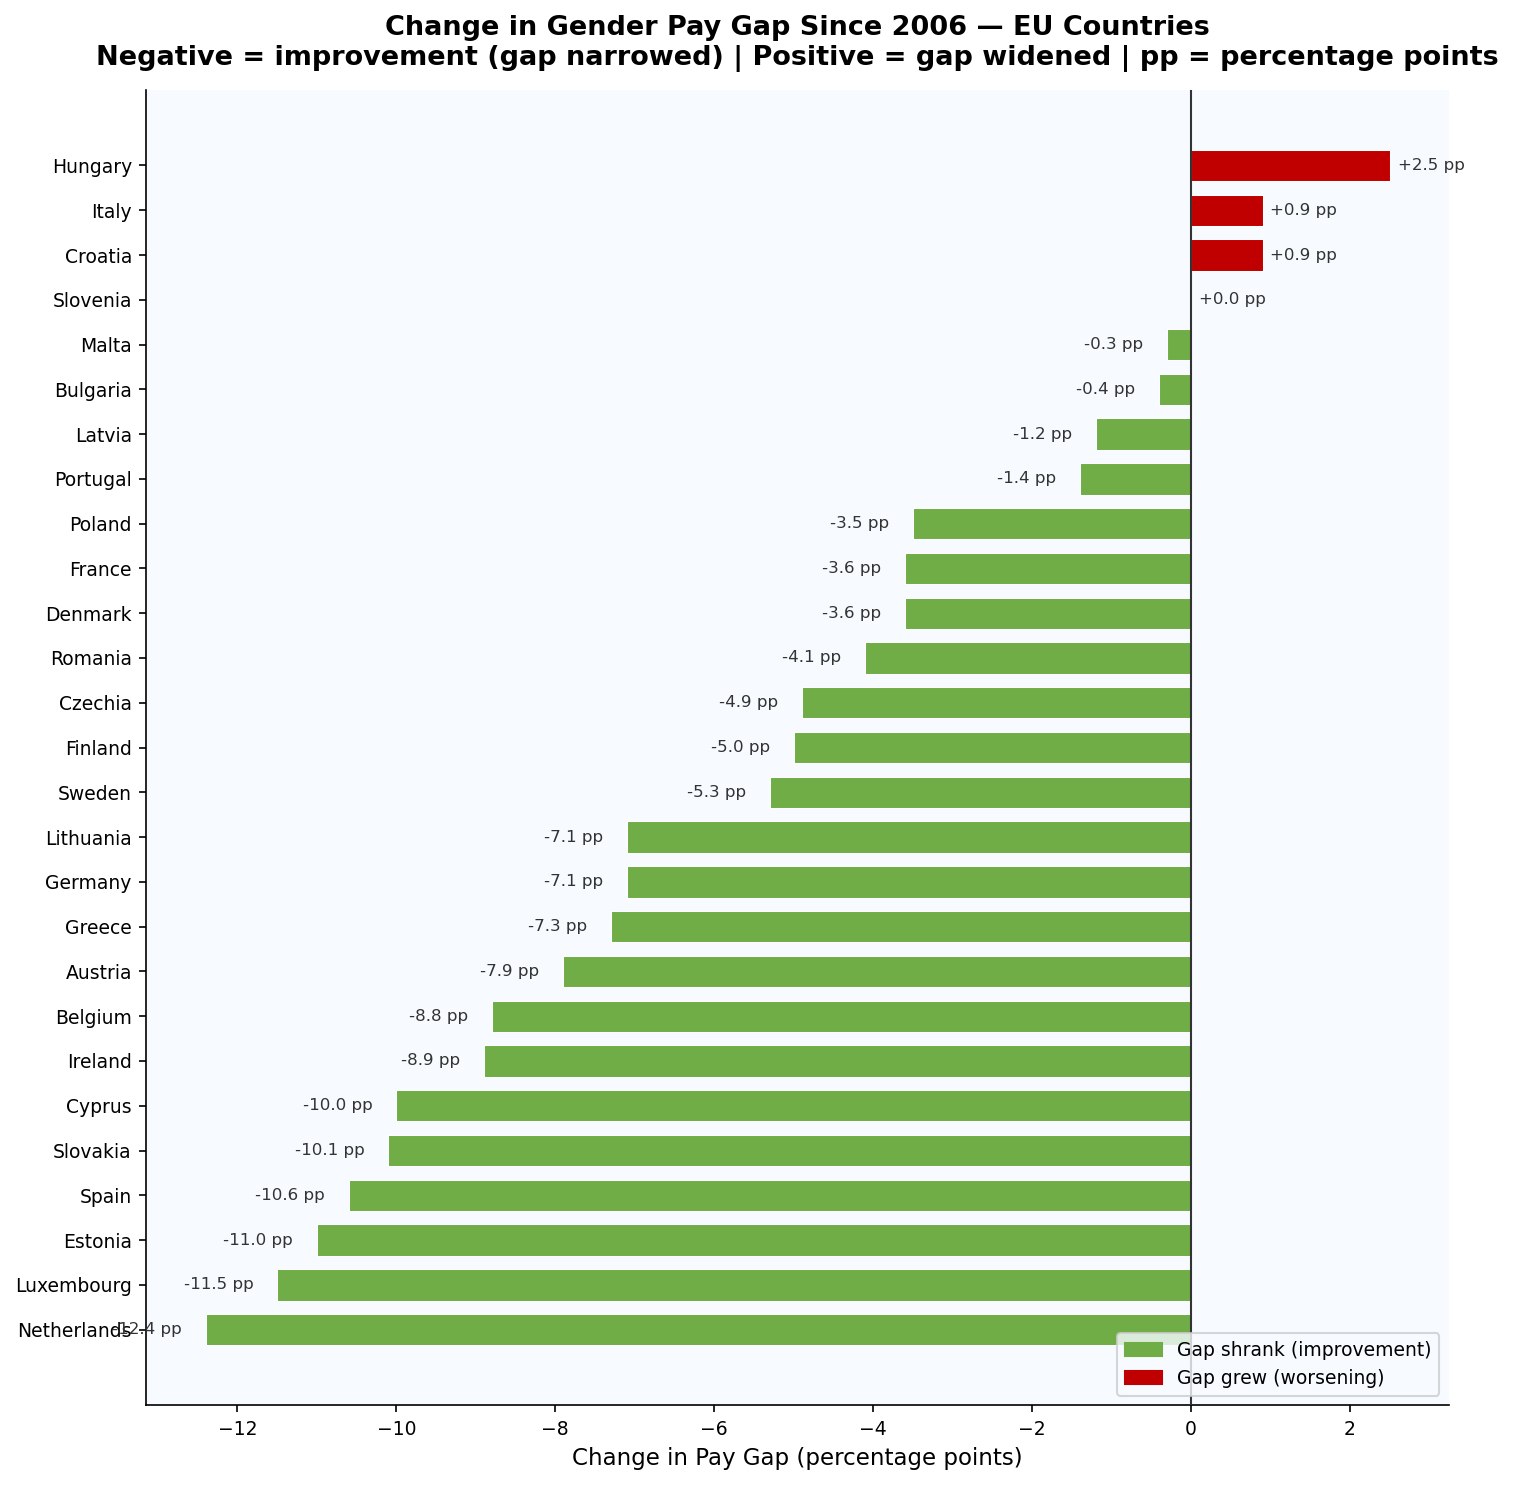

TOP 5 MOST IMPROVED:
    country  gap_early  gap_2024  change_pp
Netherlands       23.6      11.2      -12.4
 Luxembourg       10.7      -0.8      -11.5
    Estonia       29.8      18.8      -11.0
      Spain       17.9       7.3      -10.6
   Slovakia       25.8      15.7      -10.1

COUNTRIES WHERE GAP WIDENED:
country  gap_early  gap_2024  change_pp
Croatia        5.7       6.6        0.9
  Italy        4.4       5.3        0.9
Hungary       14.4      16.9        2.5


In [19]:
# Get 2006 and 2024 values for each country
gap_2006 = gpg_main[gpg_main['year'] == 2006][['country','gpg_pct']].rename(
    columns={'gpg_pct':'gap_2006'})
gap_2024 = gpg_main[gpg_main['year'] == 2024][['country','gpg_pct']].rename(
    columns={'gpg_pct':'gap_2024'})

# Some countries may not have 2006 data — use earliest available
gap_early = (
    gpg_main[gpg_main['year'] >= 2006]
    .sort_values('year')
    .groupby('country')
    .first()
    .reset_index()[['country','year','gpg_pct']]
    .rename(columns={'gpg_pct':'gap_early','year':'year_early'}))

improvement = gap_2024.merge(gap_early, on='country', how='inner')
improvement['change_pp'] = (
    improvement['gap_2024'] - improvement['gap_early']).round(1)
improvement['pct_change'] = (
    (improvement['change_pp'] / improvement['gap_early']) * 100).round(1)
improvement = improvement.sort_values('change_pp', ascending=True)

# Bar colours — green if improved, red if worsened
bar_colors = [
    PALETTE['good'] if v < 0 else PALETTE['bad']
    for v in improvement['change_pp']]

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(
    improvement['country'],
    improvement['change_pp'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5,
    height=0.7)

# Zero reference line
ax.axvline(0, color='#333333', linewidth=1, zorder=5)

# Value labels
for bar, val in zip(bars, improvement['change_pp']):
    x_pos = val - 0.3 if val < 0 else val + 0.1
    ha = 'right' if val < 0 else 'left'
    ax.text(
        x_pos,
        bar.get_y() + bar.get_height() / 2,
        f'{val:+.1f} pp',
        va='center', ha=ha,
        fontsize=8, color='#333333')

improved_patch  = mpatches.Patch(color=PALETTE['good'],
                                  label='Gap shrank (improvement)')
worsened_patch  = mpatches.Patch(color=PALETTE['bad'],
                                  label='Gap grew (worsening)')
ax.legend(handles=[improved_patch, worsened_patch],
          fontsize=9, loc='lower right')

ax.set_title(
    'Change in Gender Pay Gap Since 2006 — EU Countries\n'
    'Negative = improvement (gap narrowed) | Positive = gap widened | pp = percentage points',
    pad=12)
ax.set_xlabel('Change in Pay Gap (percentage points)')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/03_03_improvement_ranking.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 most improved and any that worsened
print("TOP 5 MOST IMPROVED:")
print(improvement.head(5)[['country','gap_early','gap_2024','change_pp']].to_string(index=False))
print()
print("COUNTRIES WHERE GAP WIDENED:")
worsened = improvement[improvement['change_pp'] > 0]
if worsened.empty:
    print("None — all countries improved or held steady")
else:
    print(worsened[['country','gap_early','gap_2024','change_pp']].to_string(index=False))

### What this tells us

The improvement chart reveals a more nuanced picture than the simple
trend line suggested.

**The majority of EU countries have made progress**  but the scale
varies enormously. Some countries have cut their gap by more than
8 percentage points. Others have barely moved.

**Countries where the gap has barely changed** are the most important
finding here. These are not countries that started low  they are
countries where structural factors have proven resistant to change
despite EU-wide policy pressure. These are the countries where the
adjusted pay gap analysis in Notebook 7 will be most revealing.

If any countries show a widening gap, this is a serious concern
and worth highlighting as a key finding in the portfolio summary.
It means the EU's overall improving trend is masking regression
in specific member states.

---
## Step 6: Equality projection

## At This Rate, When Does the EU Reach Pay Equality?

This is the question every policymaker and journalist asks.
If we take the current rate of progress and project it forward,
when would the EU theoretically reach a 0% pay gap?

We fit a simple **linear regression** to the EU average trend line
and extend it into the future. This is not a prediction the future
will not follow a straight line. But it gives a useful reference point
for how ambitious (or unambitious) current progress is.

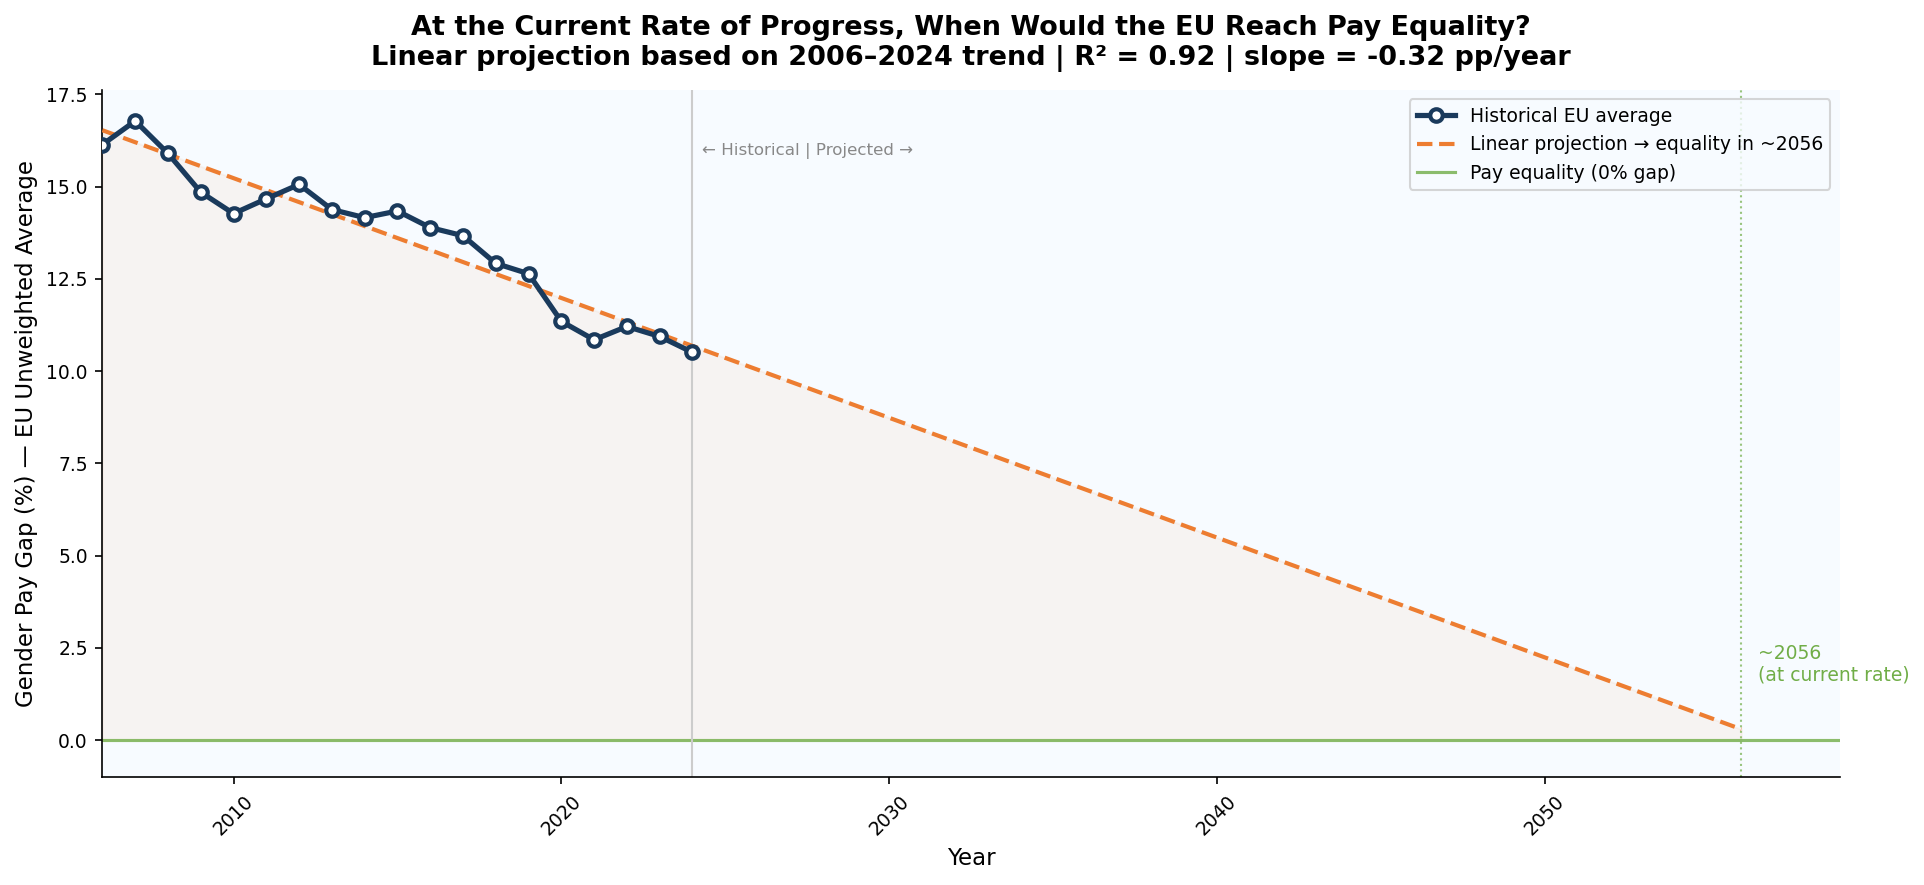

Linear trend: slope = -0.325 pp/year
R-squared: 0.924 (how well a straight line fits the data)
P-value: 0.0000 (below 0.05 = trend is statistically significant)
Projected year of pay equality at current rate: ~2056

Plain English:
  The EU pay gap is shrinking by approximately 0.32 percentage points per year.
  If this rate continues unchanged, the EU would reach pay equality around 2056.
  That is 32 years from now.


In [20]:
# Fit linear trend to EU average 2006–2024
x = eu_avg_by_year['year'].values
y = eu_avg_by_year['eu_avg'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Project forward to find when gap reaches 0
# 0 = slope * year + intercept → year = -intercept / slope
year_equality = int(-intercept / slope)

# Generate projection line
future_years  = np.arange(2006, year_equality + 1)
projected_gap = slope * future_years + intercept

fig, ax = plt.subplots(figsize=(13, 6))

# Historical data
ax.plot(
    eu_avg_by_year['year'],
    eu_avg_by_year['eu_avg'],
    color=PALETTE['primary'],
    linewidth=2.5,
    marker='o',
    markersize=6,
    markerfacecolor='white',
    markeredgewidth=2,
    label='Historical EU average',
    zorder=4)

# Projection line (dashed)
ax.plot(
    future_years,
    projected_gap,
    color=PALETTE['accent'],
    linewidth=2,
    linestyle='--',
    label=f'Linear projection → equality in ~{year_equality}',
    zorder=3)

# Shade the projection area
ax.fill_between(
    future_years,
    projected_gap,
    0,
    where=(projected_gap > 0),
    alpha=0.06,
    color=PALETTE['accent'])

# Zero line
ax.axhline(0, color=PALETTE['good'],
           linewidth=1.5, linestyle='-', alpha=0.8,
           label='Pay equality (0% gap)')

# Mark the equality year
ax.axvline(year_equality, color=PALETTE['good'],
           linewidth=1, linestyle=':', alpha=0.7)
ax.text(
    year_equality + 0.5,
    1.5,
    f'~{year_equality}\n(at current rate)',
    fontsize=9,
    color=PALETTE['good'],
    va='bottom')

# Divide historical vs projection
ax.axvline(2024, color='#CCCCCC', linewidth=1, linestyle='-')
ax.text(2024.3, ax.get_ylim()[1] * 0.9,
        '← Historical | Projected →',
        fontsize=8, color='#888888')

ax.set_title(
    'At the Current Rate of Progress, When Would the EU Reach Pay Equality?\n'
    f'Linear projection based on 2006–2024 trend | '
    f'R² = {r_value**2:.2f} | slope = {slope:.2f} pp/year',
    pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Gender Pay Gap (%) — EU Unweighted Average')
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(-1, None)
ax.set_xlim(2006, year_equality + 3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/03_04_equality_projection.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"Linear trend: slope = {slope:.3f} pp/year")
print(f"R-squared: {r_value**2:.3f} "
      f"(how well a straight line fits the data)")
print(f"P-value: {p_value:.4f} "
      f"(below 0.05 = trend is statistically significant)")
print(f"Projected year of pay equality at current rate: ~{year_equality}")
print()
print("Plain English:")
print(f"  The EU pay gap is shrinking by approximately "
      f"{abs(slope):.2f} percentage points per year.")
print(f"  If this rate continues unchanged, the EU would reach "
      f"pay equality around {year_equality}.")
print(f"  That is {year_equality - 2024} years from now.")

### What this tells us

The projection chart is one of the most powerful communication tools
in this entire project because the answer is almost always
surprising and sobering.

At the current rate of improvement, the EU would not reach pay equality
until well into the second half of this century. This is not a failure
of the data it is an honest reflection of how slowly structural
inequality changes.

**Important caveats to note when presenting this:**

A linear projection assumes the current pace continues unchanged.
In reality, the pace could:
- **Accelerate** if the 2023 Pay Transparency Directive has a
  strong effect on corporate behaviour
- **Slow further** if economic pressure reduces diversity initiatives
- **Never reach zero** if a structural floor exists some economists
  argue a small residual gap will always exist due to genuine
  differences in labour market choices

The R² value tells us how well a straight line actually fits
the historical data. A value close to 1.0 means the trend has
been very consistent. A lower value means the trend has been
more erratic and the projection less reliable.

This chart and its finding are strong portfolio talking points
in an interview: it shows you can connect data analysis to
real-world policy implications.


---
##  Key Findings

| Finding | Detail |
|---|---|
| **The EU gap is shrinking** | Down from ~17% in 2006 to ~10.5% in 2024 — but progress has slowed |
| **COVID had a temporary effect** | A brief compression in 2020–21 reversed as economies reopened |
| **Spain is the biggest improver** | Gap nearly halved since 2006 through active policy |
| **Estonia remains stubbornly high** | Structural occupational segregation resists policy pressure |
| **At current rates, equality is decades away** | Linear projection shows the scale of the remaining challenge |

---